In [1]:
import warnings;
warnings.simplefilter('ignore')
from dcr import *

In [2]:
%matplotlib inline
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (16,9)
plt.rcParams.update({'font.size': 16})

In [3]:
data, data_train, data_test, X_train_scaled, X_test_scaled, y_train, y_test = dataprep(  data, depvar='default_time', splitvar='time', threshold=26)

In [4]:
data.loc[:, 'annuity'] = ((data.loc[:,'interest_rate_time']/(100*4)) * data.loc[:,'balance_orig_time'])/ (1-(1+data.loc[:,'interest_rate_time']/(100*4))**(-(data.loc[:,'mat_time'] - data.loc[:,'orig_time'])))

In [5]:
data.loc[:,'balance_scheduled_time'] = data.loc[:,'balance_orig_time'] * (1+data.loc[:,'interest_rate_time']/(100*4))**(data.loc[:,'time'] - data.loc[:,'orig_time']) - data.  loc[:,'annuity'] * ((1+data.loc[:,'interest_rate_time']/(100*4))**(data.loc[:,'time']-  data.loc[:,'orig_time'])-1)/ (data.loc[:,'interest_rate_time']/(100*4)) 

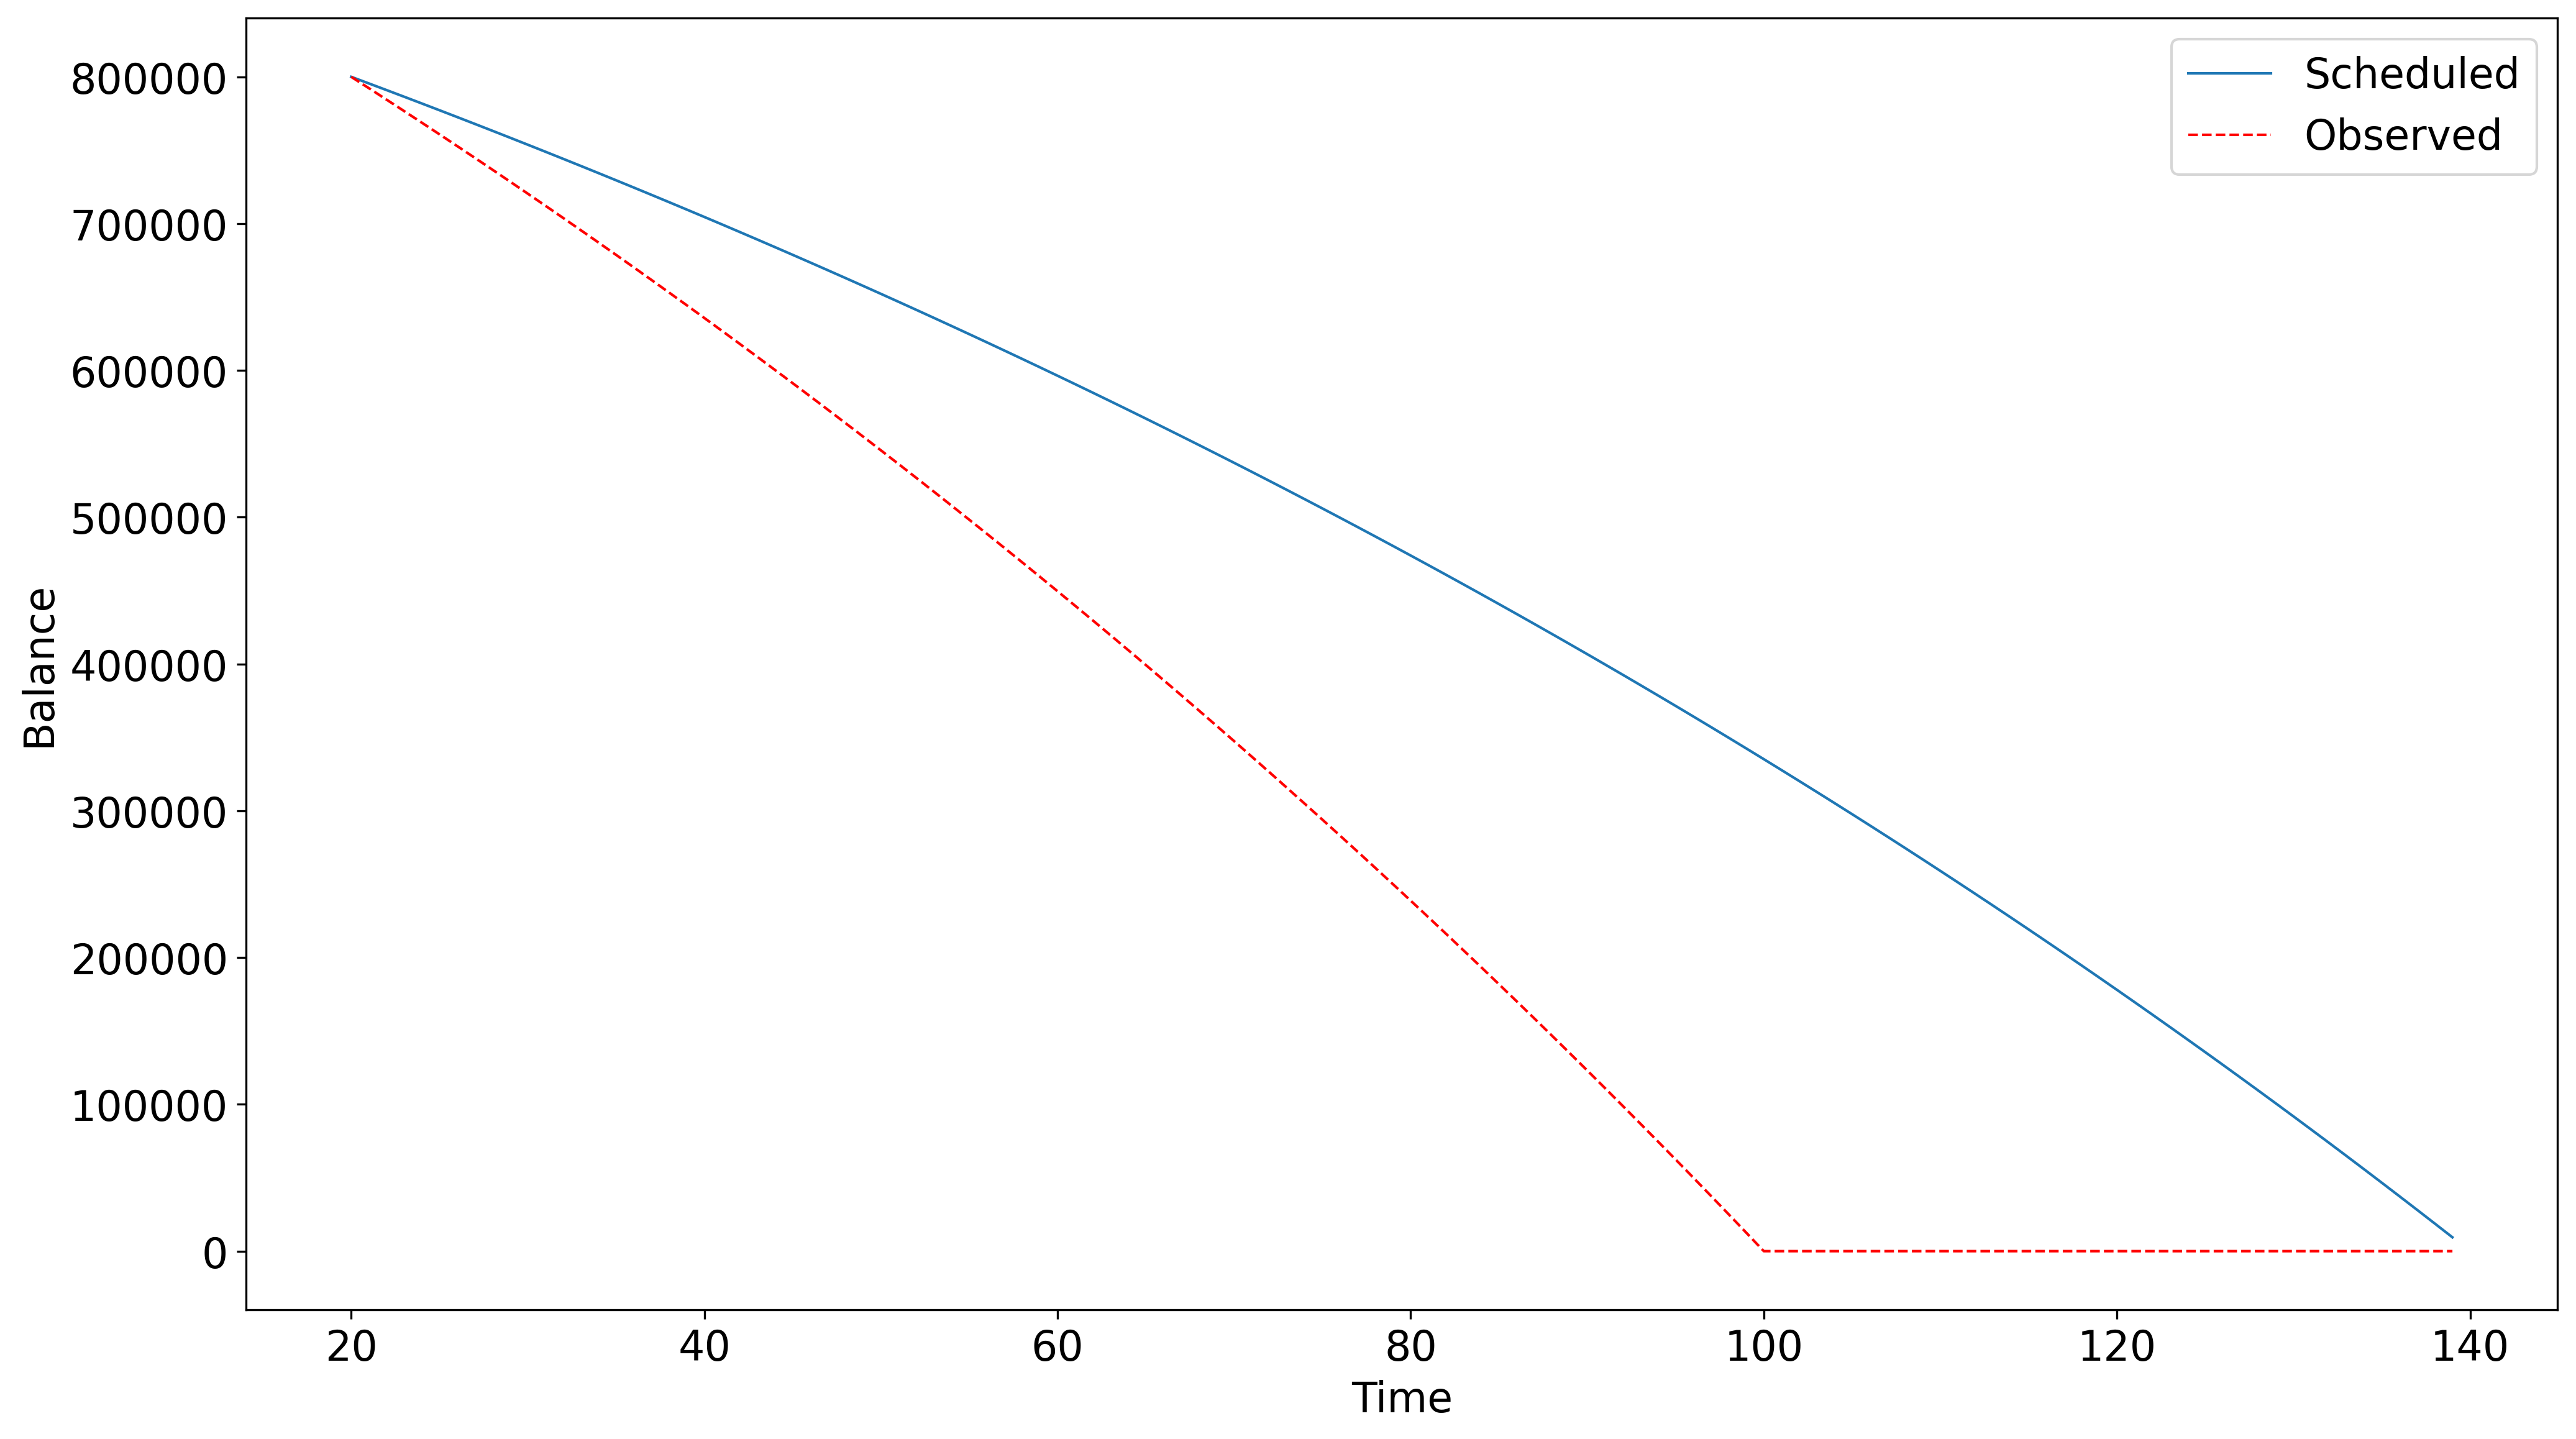

In [6]:
time = np.arange(20,140,1)  
example=pd.DataFrame(data=time, index=time, columns=["time"])  
example.loc[:, 'orig_time'] = 20  
example.loc[:, 'mat_time'] = 140
example.loc[:, 'mat_time_observed'] = 100  
example.loc[:, 'balance_orig_time'] = 800000  
example.loc[:, 'interest_rate_time'] = 2.5  
example.loc[:, 'annuity'] = ((example.loc[:,'interest_rate_time']/(100*4)) * example.loc[:,  'balance_orig_time'])/ (1-(1+example.loc[:,'interest_rate_time']/(100*4))**(-(example.loc[:,'mat_time'] - example.loc[:,'orig_time'])))  
example.loc[:, 'annuity_observed'] = ((example.loc[:,'interest_rate_time']/(100*4)) *  example.loc[:,'balance_orig_time'])/ (1-(1+example.loc[:,'interest_rate_time']/(100*4)  )**(-(example.loc[:,'mat_time_observed'] - example.loc[:,'orig_time'])))  
example.loc[:, 'balance_scheduled_time'] = example.loc[:,'balance_orig_time'] * (1+example.loc[:,'interest_rate_time']/(100*4))**(example.loc[:,'time'] - example.loc[:,'orig_time']) - example.loc[:,'annuity'] * ((1+example.loc[:,'interest_rate_time']/(100*4))**(example.loc[:,'time']-example.loc[:,'orig_time'])-1)/ (example.loc[:,'interest_rate_time']/(100*4))  
example.loc[:, 'balance_time'] = example.loc[:,'balance_orig_time'] * (1+example.loc[:,'interest_rate_time']/(100*4))**(example.loc[:,'time'] - example.loc[:,'orig_time']) -  example.loc[:,'annuity_observed'] * ((1+example.loc[:,'interest_rate_time']/(100*4))**(example.loc[:,'time']-example.loc[:,'orig_time'])-1)/ (example.loc[:,'interest_rate_time']/(100*4)) 
example = example.clip(lower=0)  

plt.plot('time', 'balance_scheduled_time', data=example, linewidth=1, label='Scheduled')  
plt.plot('time', 'balance_time', data=example, color='red', linewidth=1, label='Observed',  linestyle='dashed')  
plt.xlabel('Time')  
plt.ylabel('Balance')  
plt.legend(loc='best')  

plt.show()

In [7]:
data.loc[:,'property_orig_time'] = np.maximum(data.loc[:,'balance_orig_time'] / (data.loc[:,'LTV_orig_time']/100),100000) 
data.loc[:,'cep_time']= (data.loc[:,'balance_scheduled_time'] - data.loc[:,'balance_time'])  / data.loc[:,'property_orig_time']

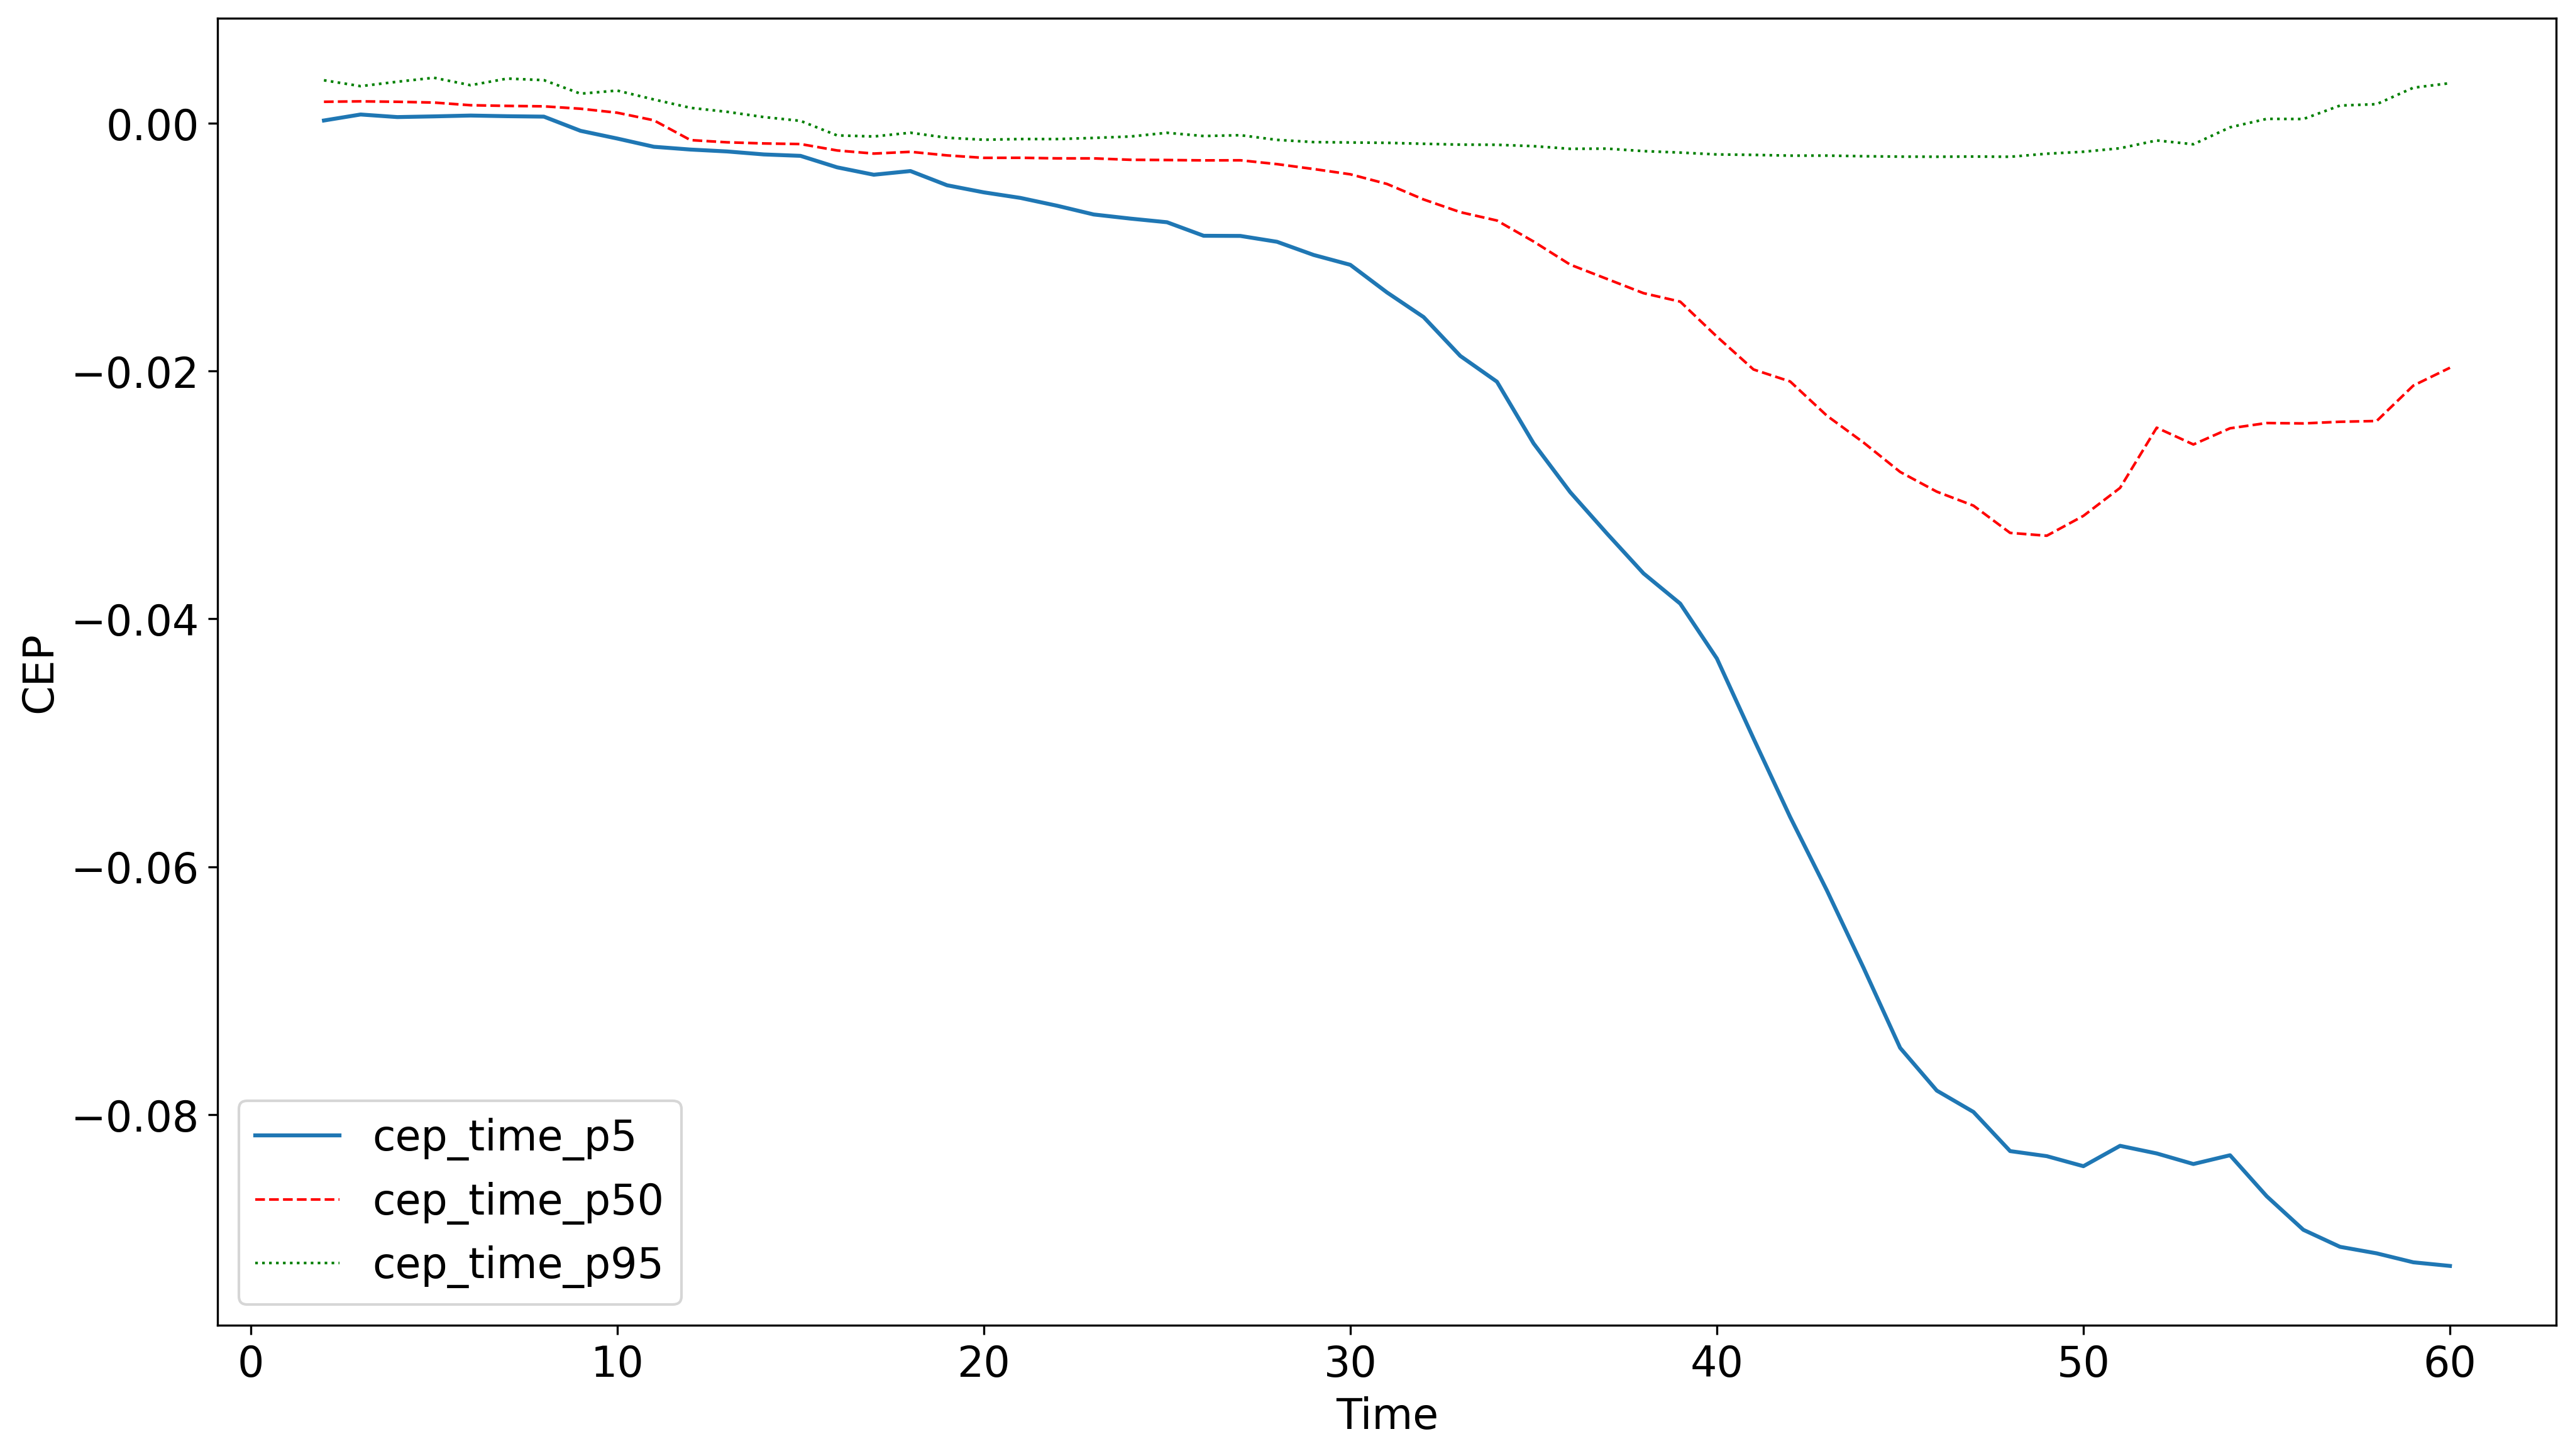

In [8]:
cep_time_p25 = data.groupby('time')['cep_time'].quantile(0.25).reset_index(drop=False)  
cep_time_p50 = data.groupby('time')['cep_time'].median().reset_index(drop=False)  
cep_time_p75 = data.groupby('time')['cep_time'].quantile(0.75).reset_index(drop=False)  
plt.plot('time', 'cep_time', data=cep_time_p25, label='cep_time_p5')  
plt.plot('time', 'cep_time', data=cep_time_p50, color='red', linewidth=1, label='cep_time_p50',linestyle='dashed') 
plt.plot('time', 'cep_time', data=cep_time_p75, color='green', linewidth=1, label='cep_time_p95',linestyle='dotted')  
plt.xlabel('Time')  
plt.ylabel('CEP')  
plt.legend(loc='best')  
plt.show() 

In [9]:
data.loc[:,'equity_time'] = 1-(data.loc[:,'LTV_time']/100)

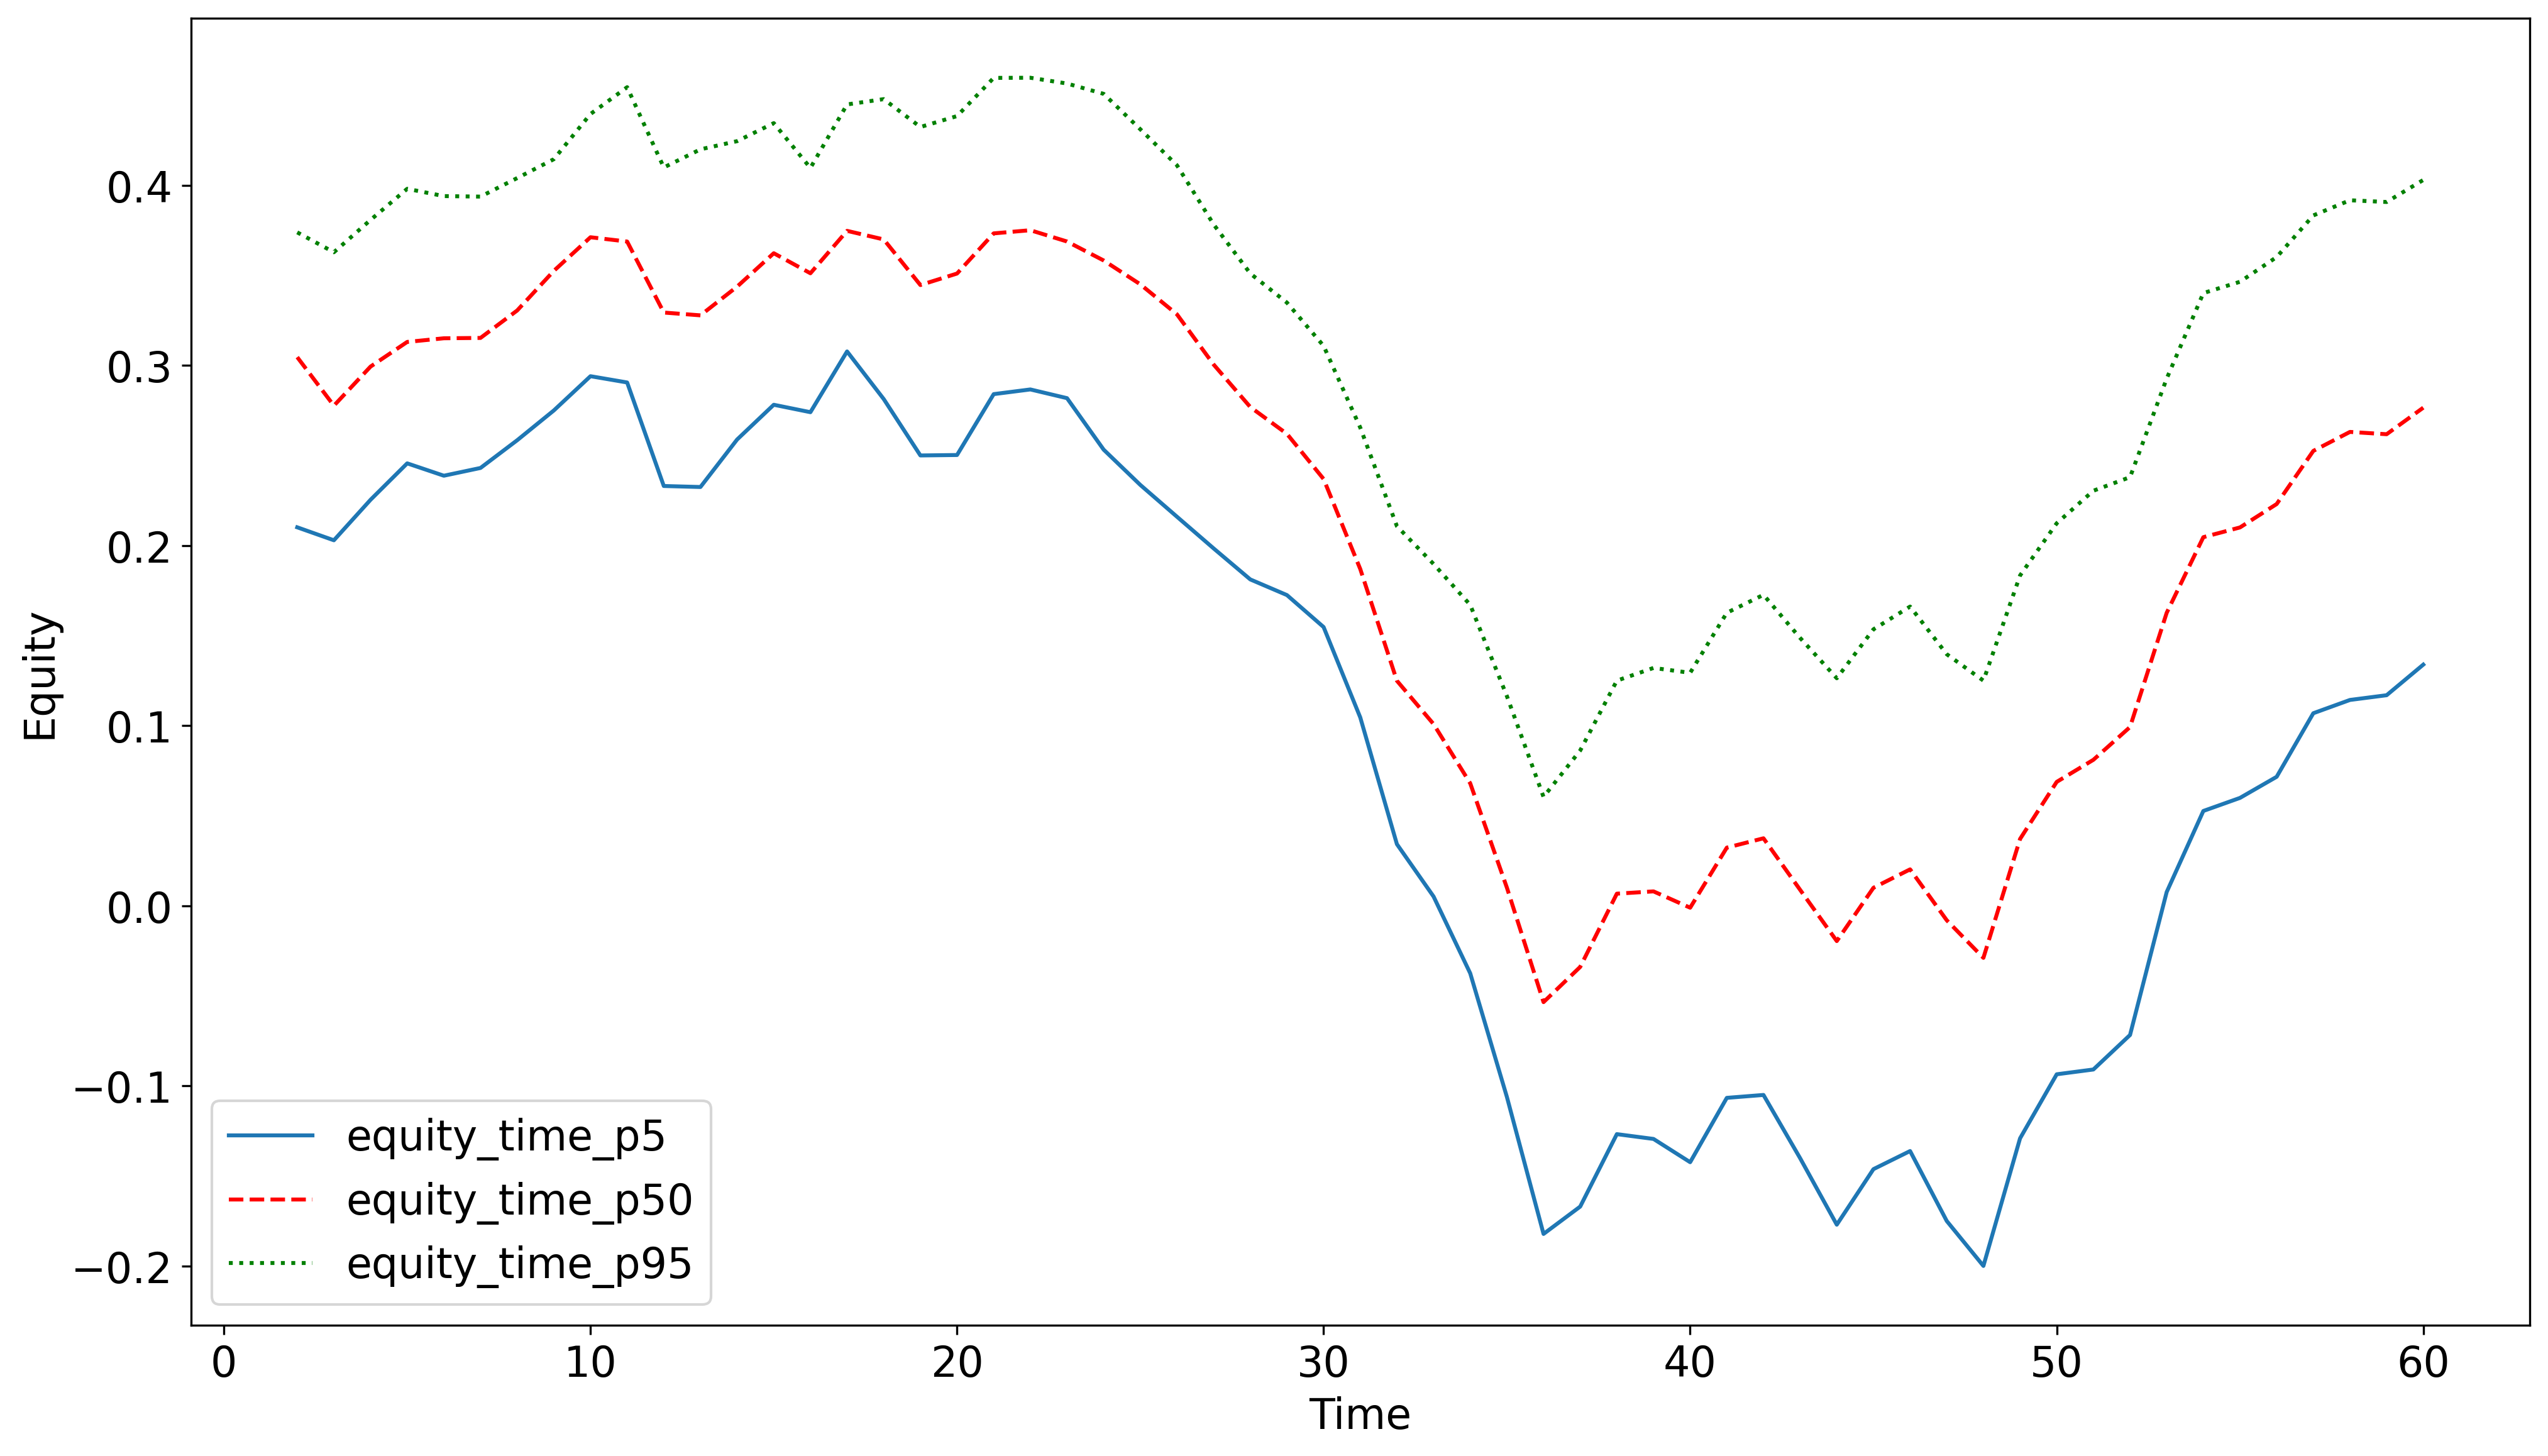

In [10]:
equity_time_p25 = data.groupby('time')['equity_time'].quantile(0.25).reset_index(drop=False  )  
equity_time_p50 = data.groupby('time')['equity_time'].mean().reset_index(drop=False)  
equity_time_p75 = data.groupby('time')['equity_time'].quantile(0.75).reset_index(drop=False  )  

plt.plot('time', 'equity_time', data=equity_time_p25, label='equity_time_p5')  
plt.plot('time', 'equity_time', data=equity_time_p50, color='red', label='equity_time_p50',  linestyle='dashed')  
plt.plot('time', 'equity_time', data=equity_time_p75, color='green', label='equity_time_p95',linestyle='dotted')  
plt.xlabel('Time')  
plt.ylabel('Equity')
plt.legend(loc='best')
plt.show() 

In [11]:
data2=data[['cep_time', 'equity_time']]  
print(data2.corr(method='pearson').round(decimals=2))  

             cep_time  equity_time
cep_time         1.00         0.61
equity_time      0.61         1.00


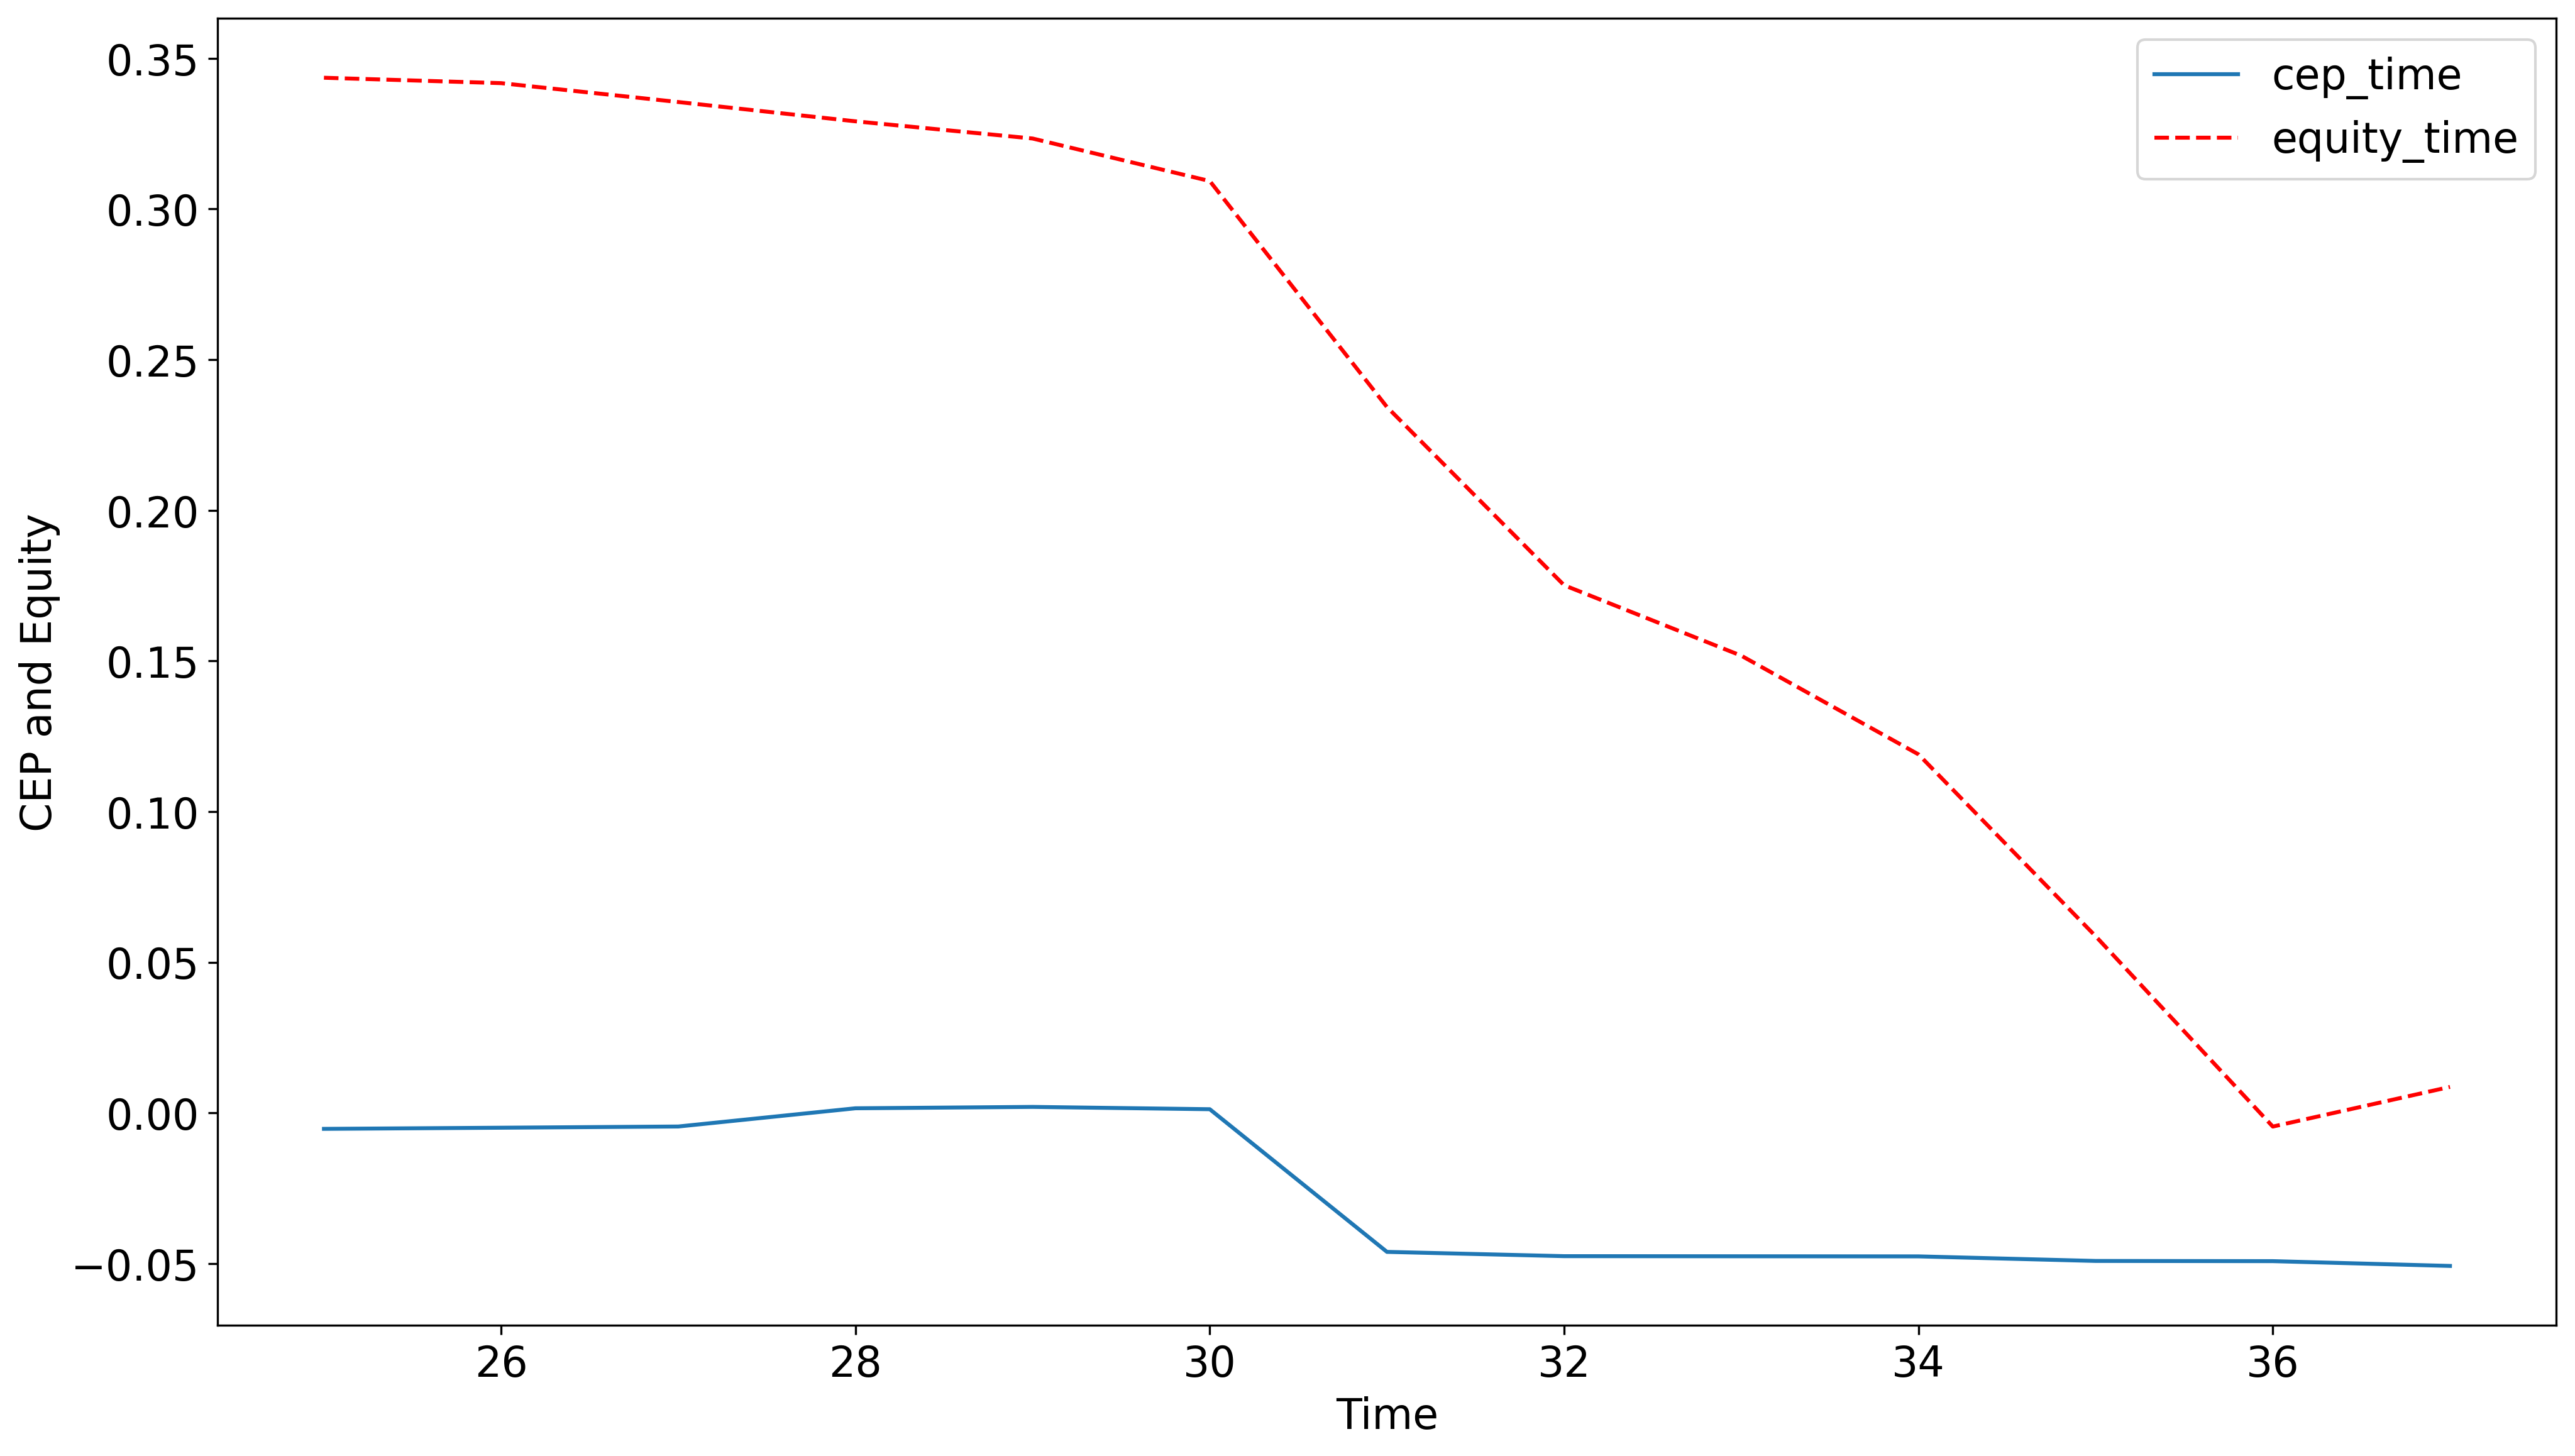

In [12]:
data2=data.loc[(data.id == 9),['time', 'cep_time', 'equity_time']]  
plt.plot('time', 'cep_time', data=data2, label='cep_time')  
plt.plot('time', 'equity_time', data=data2, color='red', label='equity_time',linestyle='dashed') 
plt.xlabel('Time')  
plt.ylabel('CEP and Equity')  
plt.legend(loc='best') 

In [13]:
data.loc[:,'age'] = data.loc[:,'time']-data.loc[:,'orig_time']  
data.loc[data['age'] >= 40, 'age'] = 40  
data.loc[:, 'age2']=data.loc[:,'age']**2  
data.loc[:, 'vintage'] = data.loc[:,'orig_time']  
data.loc[data['vintage'] < 0, 'vintage'] = 0  
data.loc[data['vintage'] >= 30, 'vintage'] = 30  
data.loc[:, 'vintage2']=data.loc[:,'vintage']**2 

In [14]:
data.loc[:, 'state_orig_time'] = pd.Categorical(data.state_orig_time, ordered=False) 

In [15]:
data2 = data[['default_time', 'LTV_time', 'interest_rate_time', 'hpi_time',  'gdp_time', 'uer_time', 'REtype_CO_orig_time', 'REtype_PU_orig_time', 'FICO_orig_time', 'LTV_orig_time']].copy()  
data2.dropna(inplace=True)  
mean = data2.groupby('default_time').mean().transpose()  
dt0 = data2.query('default_time == 0') 
dt1 = data2.query('default_time == 1') 
dt0 = dt0.drop('default_time', axis=1) 
dt1 = dt1.drop('default_time', axis=1) 
ttest1 = ttest_ind(dt0, dt1, equal_var = True).pvalue  
ttest2 = abs(ttest_ind(dt0, dt1, equal_var = True).statistic)  
ttest1 = pd.DataFrame(ttest1, columns = ['pValue'])  
ttest2 = pd.DataFrame(ttest2, columns = ['tStat']) 
new_index= mean.index.tolist() 
ttest1.index = new_index  
ttest2.index = new_index  
print(pd.concat([mean, ttest1, ttest2], axis=1).round(decimals=2).sort_values(by=['tStat'],  ascending=False))

                        0.0     1.0  pValue  tStat
LTV_time              83.03   97.75    0.00  19.96
gdp_time               1.41    0.48    0.00  18.02
interest_rate_time     6.60    7.55    0.00  17.35
FICO_orig_time       675.23  650.57    0.00  13.10
hpi_time             184.45  175.69    0.00  11.98
LTV_orig_time         78.44   81.00    0.00   9.54
uer_time               6.49    6.89    0.00   7.76
REtype_CO_orig_time    0.06    0.05    0.18   1.33
REtype_PU_orig_time    0.13    0.14    0.69   0.40


In [16]:
data2=data[['default_time', 'LTV_time', 'interest_rate_time', 'hpi_time', 'gdp_time', 'uer_time', 'REtype_CO_orig_time', 'REtype_PU_orig_time', 'FICO_orig_time', 'LTV_orig_time']].dropna()  
X = data2[['LTV_time', 'interest_rate_time', 'hpi_time', 'gdp_time', 'uer_time', 'REtype_CO_orig_time', 'REtype_PU_orig_time', 'FICO_orig_time', 'LTV_orig_time']].values  
y = data2[['default_time']].values.reshape(-1,) 
transformer1 = f_classif(X, y) 
print('F-statistics and p-values:')  
print(np.round(transformer1,1))  
transformer2 = SelectKBest(f_classif, k=5) 
X2 = transformer2.fit_transform(X, y)  
print('5 best variables:')  
print(transformer2.get_support()) 

F-statistics and p-values:
[[3.982e+02 3.011e+02 1.435e+02 3.246e+02 6.020e+01 1.800e+00 2.000e-01
  1.716e+02 9.090e+01]
 [0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 2.000e-01 7.000e-01
  0.000e+00 0.000e+00]]
5 best variables:
[ True  True  True  True False False False  True False]


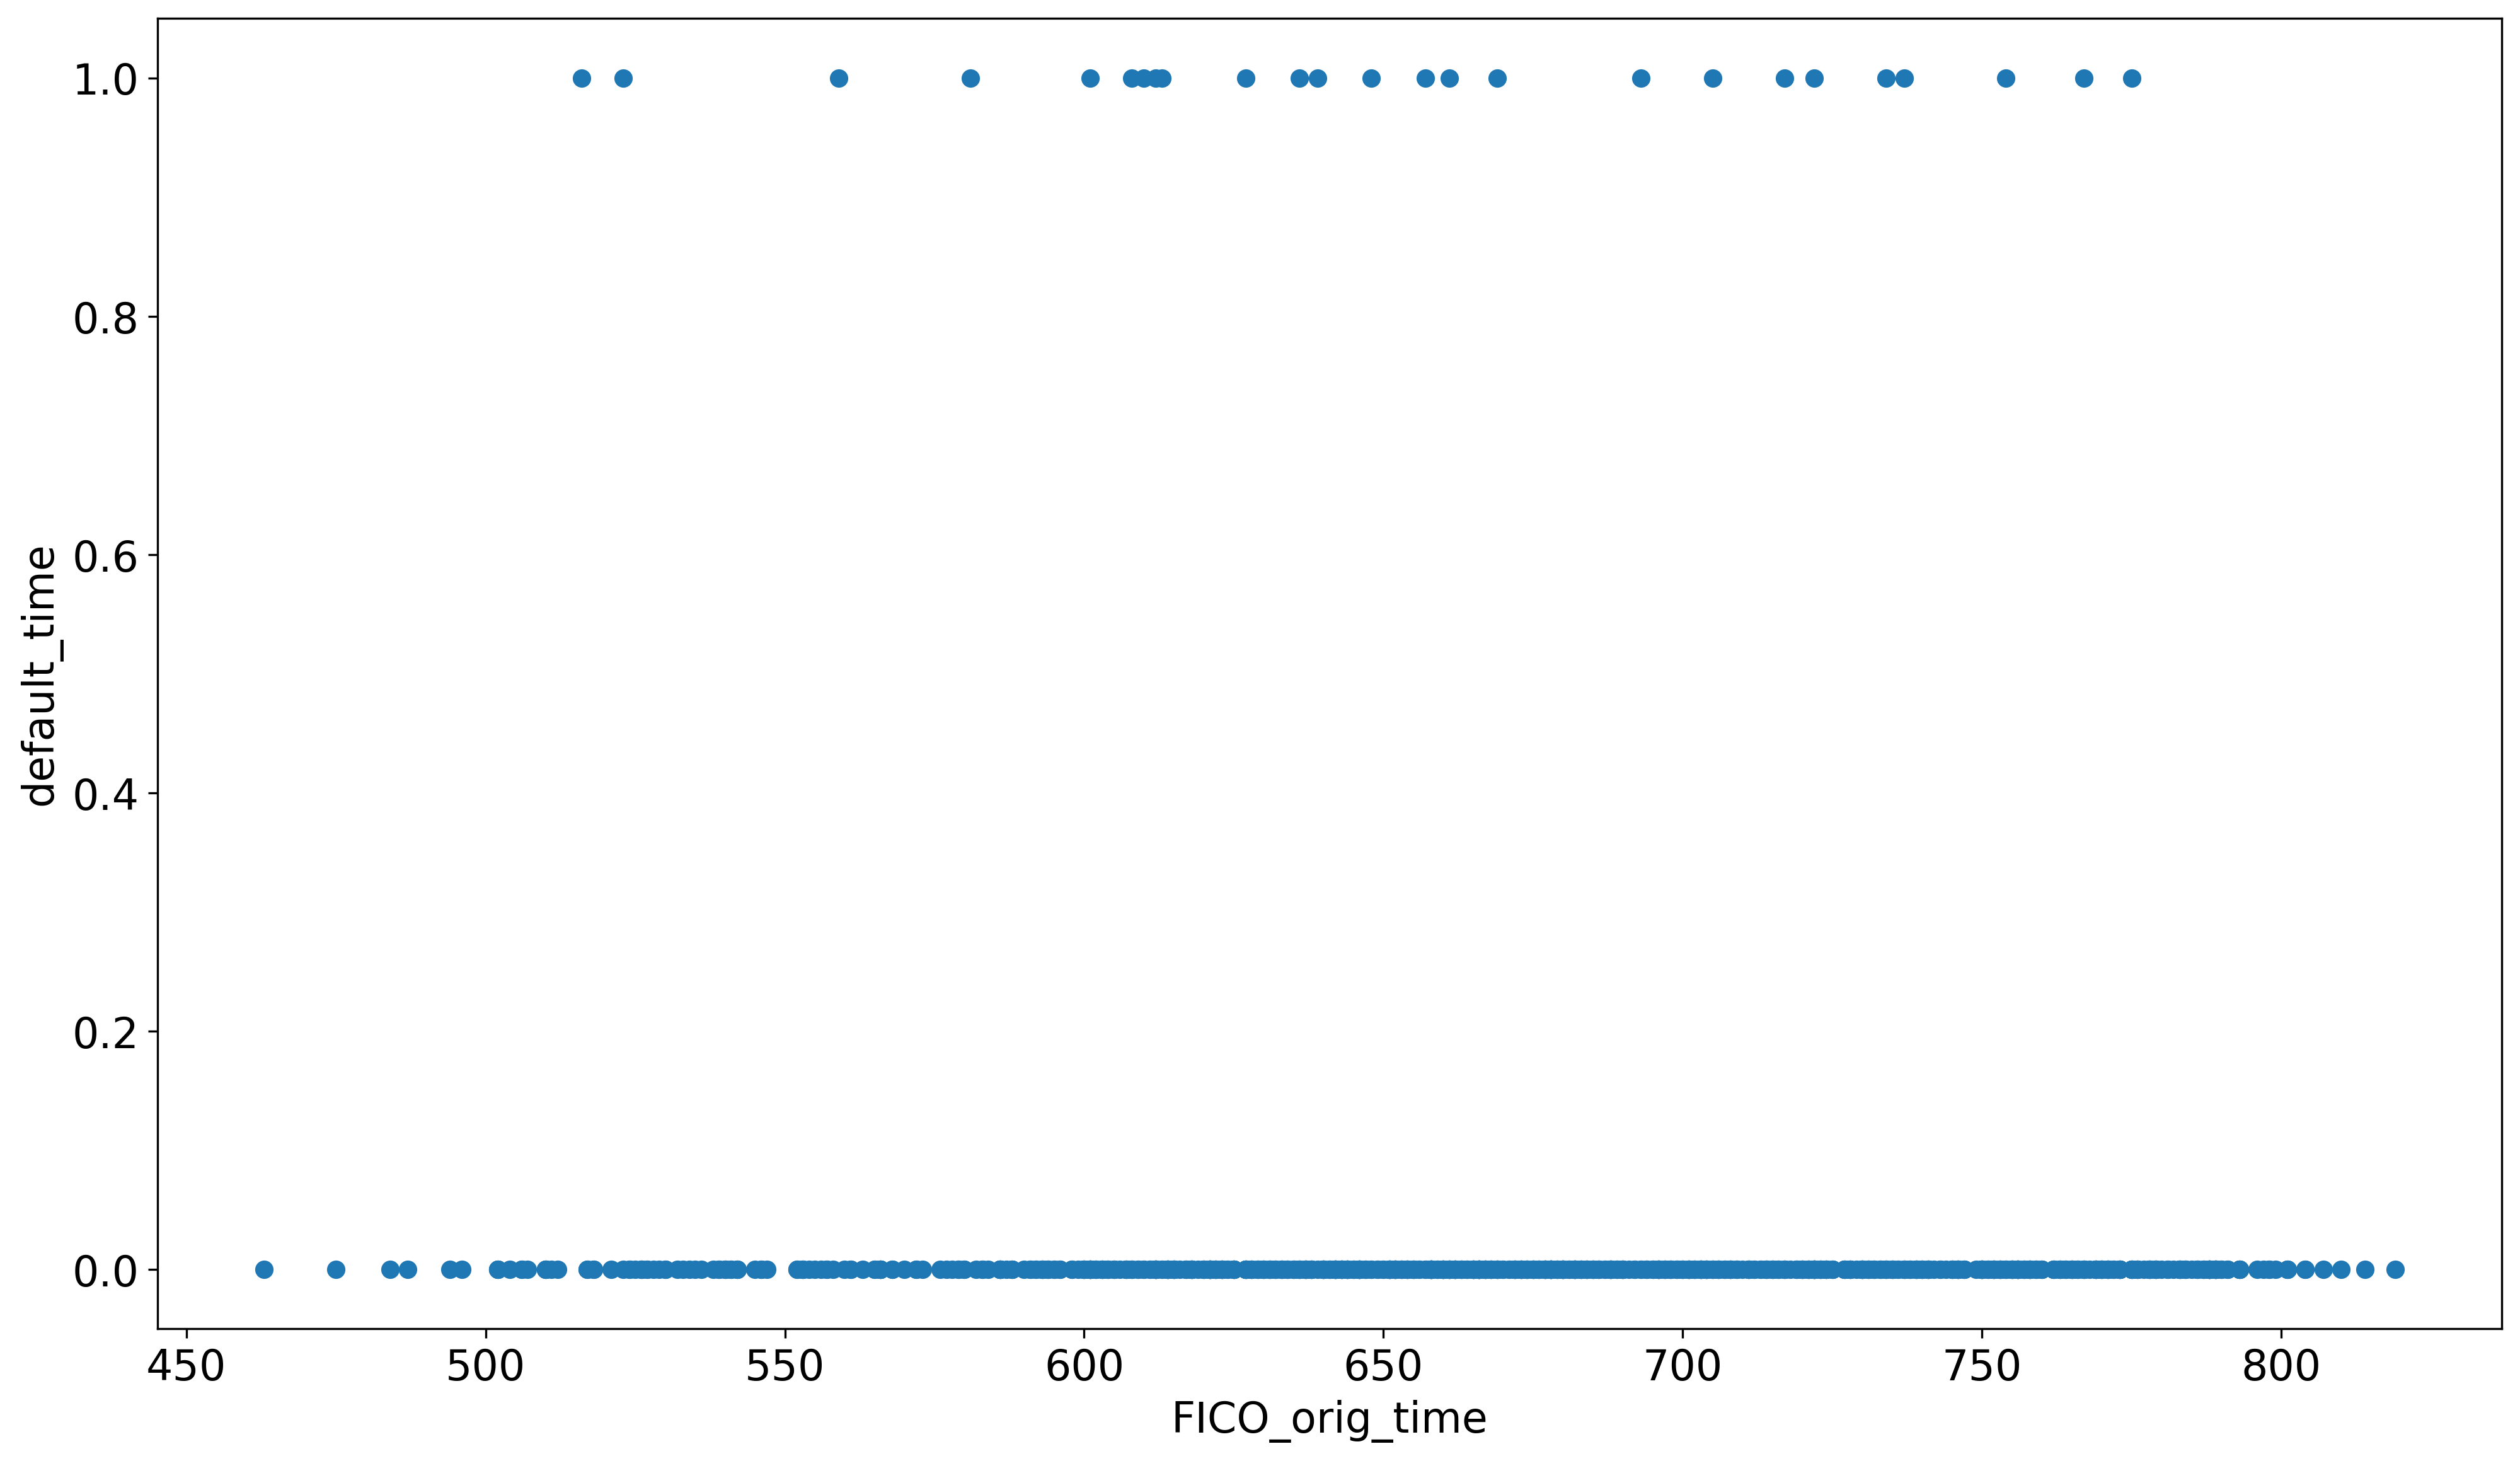

In [17]:
data2 = data.sample(1000, random_state=12345) 
data2 = data2[['default_time', 'FICO_orig_time']]  
plt.scatter('FICO_orig_time', 'default_time', data=data2)  
plt.xlabel('FICO_orig_time')  
plt.ylabel('default_time')  
plt.show()  

In [18]:
print(data2.corr(method='pearson').round(decimals=2)) 

                default_time  FICO_orig_time
default_time            1.00           -0.04
FICO_orig_time         -0.04            1.00


In [19]:
data2, outputIV1 = woe(data_in=data, target='default_time', variable='LTV_time', bins=10,  binning='True') 
data2, outputIV2 = woe(data_in=data2, target='default_time', variable='interest_rate_time',  bins=10, binning='True') 
data2, outputIV3 = woe(data_in=data2, target='default_time', variable='FICO_orig_time',  bins=10, binning='True')  
data2, outputIV4 = woe(data_in=data2, target='default_time', variable='hpi_time', bins=5,  binning='True')  
data2, outputIV5 = woe(data_in=data2, target='default_time', variable='gdp_time', bins=5,  binning='True')  
data2, outputIV6 = woe(data_in=data2, target='default_time', variable='uer_time', bins=5,  binning='True')  
data2, outputIV7 = woe(data_in=data2, target='default_time', variable='LTV_orig_time', bins=5, binning='True')  
data2, outputIV8 = woe(data_in=data2, target='default_time', variable='REtype_CO_orig_time'  , bins=0, binning='False')  
data2, outputIV9 = woe(data_in=data2, target='default_time', variable='REtype_PU_orig_time'  , bins=0, binning='False')

print(pd.concat([outputIV1, outputIV2, outputIV3, outputIV4, outputIV5, outputIV6,  outputIV7, outputIV8, outputIV9]).round(decimals=2))

                  name    IV
0             LTV_time  0.47
0   interest_rate_time  0.31
0       FICO_orig_time  0.16
0             hpi_time  0.12
0             gdp_time  0.22
0             uer_time  0.04
0        LTV_orig_time  0.07
0  REtype_CO_orig_time  0.00
0  REtype_PU_orig_time  0.00


In [20]:
data3 = data2[['LTV_time_WOE', 'interest_rate_time_WOE', 'hpi_time_WOE', 'gdp_time_WOE', 'uer_time_WOE', 'FICO_orig_time_WOE', 'LTV_orig_time_WOE']]  
print(data3.corr(method='pearson').round(decimals=2)) 

                        LTV_time_WOE  interest_rate_time_WOE  hpi_time_WOE  \
LTV_time_WOE                    1.00                    0.09          0.49   
interest_rate_time_WOE          0.09                    1.00         -0.02   
hpi_time_WOE                    0.49                   -0.02          1.00   
gdp_time_WOE                    0.41                    0.09          0.43   
uer_time_WOE                    0.42                   -0.12          0.72   
FICO_orig_time_WOE              0.01                    0.40         -0.02   
LTV_orig_time_WOE               0.36                    0.17         -0.03   

                        gdp_time_WOE  uer_time_WOE  FICO_orig_time_WOE  \
LTV_time_WOE                    0.41          0.42                0.01   
interest_rate_time_WOE          0.09         -0.12                0.40   
hpi_time_WOE                    0.43          0.72               -0.02   
gdp_time_WOE                    1.00          0.21               -0.03   
uer_t

In [21]:
scaler = StandardScaler().fit(X)  
X_scaled = scaler.transform(X)  
model_lr = LogisticRegression(penalty='none', fit_intercept=True, C=1e15, solver='saga',  tol=1e-15, max_iter=1000)  
model_lr.fit(X_scaled, y)  
print('Coefficients:', model_lr.coef_.round(2))  
print('Intercept:', model_lr.intercept_.round(2))  
predictions = model_lr.predict_proba(X_scaled)  
print('Log Loss:', log_loss(y, predictions).round(2))

Coefficients: [[ 0.2   0.34 -0.12 -0.26  0.02  0.02  0.08 -0.24  0.12]]
Intercept: [-3.91]
Log Loss: 0.11


In [22]:
model_lr_select = SelectFromModel(model_lr, threshold='median')  
model_lr_select.fit(X_scaled, y)  
n_features = model_lr_select.transform(X_scaled).shape[1]  
print('Number of features:', n_features)  
print('Coefficients:', model_lr_select.estimator_.coef_.round(2)) 
print('Threshold', model_lr_select.threshold_.round(2))  
print('Selection:', model_lr_select.get_support())

Number of features: 5
Coefficients: [[ 0.2   0.34 -0.12 -0.26  0.02  0.02  0.08 -0.24  0.12]]
Threshold 0.12
Selection: [ True  True False  True False False False  True  True]


In [23]:
model_lr_select1 = RFE(model_lr,n_features_to_select=5, step=1, verbose=1)  
model_lr_select1 = model_lr_select1.fit(X_scaled, y)  
print('Feature selection:', model_lr_select1.support_)  
print('Number of features:', model_lr_select1.n_features_) 
print('Ranking:', model_lr_select1.ranking_) 
predictions_select1 = model_lr_select1.predict_proba(X_scaled) 
print('Log Loss:', log_loss(y, predictions_select1).round(2))

Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 6 features.
Feature selection: [ True  True  True  True False False False  True False]
Number of features: 5
Ranking: [1 1 1 1 5 4 3 1 2]
Log Loss: 0.11


In [24]:
model_lr_select2 = RFECV(model_lr,min_features_to_select=5, step=1, cv=5, verbose=1, n_jobs=2) 
model_lr_select2 = model_lr_select2.fit(X_scaled, y)  

print('Feature selection:', model_lr_select2.support_)  
print('Number of features:', model_lr_select2.n_features_)  
print('Ranking:', model_lr_select2.ranking_) 
predictions_select2 = model_lr_select2.predict_proba(X_scaled) 
print('Log Loss:', log_loss(y, predictions_select2).round(4))

Fitting estimator with 9 features.
Fitting estimator with 8 features.
Feature selection: [ True  True  True  True False False  True  True  True]
Number of features: 7
Ranking: [1 1 1 1 3 2 1 1 1]
Log Loss: 0.1098


In [25]:
model_lr_reg1 = LogisticRegression(penalty='l1', fit_intercept=True, C=0.1, solver='saga',  tol=1e-15, max_iter=1000)  
model_lr_reg1.fit(X_scaled, y)  
print('Coefficients:', model_lr_reg1.coef_.round(2))  
print('Intercept:', model_lr_reg1.intercept_.round(2))  
predictions_reg1 = model_lr_reg1.predict_proba(X_scaled)  
print('Log Loss:', log_loss(y, predictions_reg1).round(2))

Coefficients: [[ 0.19  0.33 -0.12 -0.25  0.01  0.01  0.07 -0.23  0.12]]
Intercept: [-3.9]
Log Loss: 0.11


In [26]:
np.random.seed(12345)  
penalty = ["l1", "l2"]  
C_range = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1]  
params_lr = {'penalty': penalty,  'C': C_range}  
model_lr_reg = LogisticRegression(fit_intercept=True, solver='saga', tol =1e-15, max_iter  =1000)  
gs_lr = GridSearchCV(model_lr_reg, params_lr, verbose=2, n_jobs=2, cv=5, scoring = 'neg_log_loss')  
gs_lr.fit(X_scaled, y)  
print(gs_lr.best_params_)

Fitting 5 folds for each of 14 candidates, totalling 70 fits
{'C': 0.01, 'penalty': 'l1'}


In [27]:
model_lr_best = LogisticRegression(  penalty = gs_lr.best_params_.get('penalty'),  C = gs_lr.best_params_.get('C'),  fit_intercept=True, solver='saga', tol =1e-15, max_iter=1000  ) 
model_lr_best.fit(X_scaled, y)  
print('Coefficients:', model_lr_best.coef_.round(2))  
print('Intercept:', model_lr_best.intercept_.round(2))  
predictions_lr_best = model_lr_best.predict_proba(X_scaled)  
print('Log Loss:', log_loss(y, predictions_lr_best).round(2))

Coefficients: [[ 0.18  0.29 -0.07 -0.24  0.    0.    0.   -0.18  0.06]]
Intercept: [-3.83]
Log Loss: 0.11
